# ADAPT VQE

> The **Adaptive Derivative-Assembled Pseudo-Trotter Variational Quantum Eigensolver (ADAPT-VQE)** [[1](#ADAPT-VQE)] is a variational hybrid algorithm, which constitutes an extension of the Variational Quantum Eigensolver (VQE) framework [[2](#VQE)], that constructs problem-specific ansätze in a systematic and adaptive manner. Instead of relying on a fixed, heuristic circuit structure, ADAPT-VQE iteratively grows the state ansatz by selecting operators from a predefined pool based on their energy gradients with respect to the current variational state. At each iteration, the operator that yields the largest energy reduction is appended to the circuit and its parameters are reoptimized. This adaptive procedure significantly reduces the number of variational parameters and circuit depth, making ADAPT-VQE particularly well suited for near-term quantum hardware. Importantly, the algorithm is heuristic, leading to an approximate solution with no proven convergence guarantees.  
>
> The algorithm treats the following problem:
>
> - **Input:** System Hamiltonian $H$, reference state $| \Psi_{\text{ref}}\rangle$ and an operator pool of anti-Hermitian operators ${\cal O} =\{O_1,\dots,O_M\}$.
> - **Output:** Approximation of the ground state and energy of $H$.
>
> **Complexity:** The major overhead generally comes from the evaluation of the elements of the energy gradient by repeated measurements of different observables. We therefore focus on the measurement complexity of the algorithm. The complexity depends on the chosen operator pool and classical optimization scheme. The total cost incorporates the two main components of the algorithm, (i) evaluating the energy gradient, and (ii) re-optimization of the current state-ansatz (corresponds to the standard VQE optimization). As a result, at each iteration step the cost is a sum of two terms, corresponding to the two algorithm components:
$$\text{Cost}\approx \sum_{k = 1}^K (M \cdot C_G(n)+ N_{\text{opt}^{(k)}}\cdot C_E(n))~~,$$ where $n$ is the number of qubits, $K$ is the total number of iterations, $C_G(n)$ is the measurement cost to estimate a single operator gradient, $N_{\text{opt}}^{(k)}$ is the number of optimizer steps at iteration $k$, and $C_E(n)$ is the measurement cost to estimate the energy once. 
> 
> ---
>
> **Keywords:**  Variational quantum algorithm, Chemistry, Optimization

## Overview

The following  notebook begins with a theoretical explanation of the algorithm. We then consider an explicit example, consisting of a system of four qubits. The ADAPT-VQE algorithm is employed to evaluate the ground state energy and state. Following, we provide a modified version of the algorithm, and the results of both versions of the ADAPT-VQE algorithms are compared to the results obtained by the standard VQE algorithm. The notebook concludes with a short summary and analysis of the algorithm and results.

## Algorithm Steps
The algorithm builds and constructs the ansatz iteratively, one operator at a time, including only the most significant operators. This approach builds a minimal, problem-specific ansatz, avoiding unnecessary parameters and allowing systematic improvement of the accuracy. Similarly to VQE, the algorithms essentially reduce the circuit depth at the expense of measurements. 

Initially, we define an operator pool ${\cal O}=\{O_1,O_2,\cdots,O_M\}$, containing a collection of anti-Hermitian operators that are employed in the ansatz construction.

We then follow the following procedure:
1. Initialize the qubits to the reference state, $| \Psi_{\text{ref}}\rangle$, and define the initial iterative state as $| \psi^{(0)}\rangle = | \Psi_{\text{ref}} \rangle$.
2. Prepare a trial quantum state with the current ansatz, denoted by $|\psi^{(k)}\rangle$, where $k=0,1,\dots$ corresponds to the iteration step number (initially set to zero).
3. Measure the commutator of the Hamiltonian with the operators of $\cal{O}$. The expectation value corresponds to the partial derivative of the energy (in the $k$ iteration step) with respect to the coefficient of $O_j$: $$\frac{\partial E^{(k+1)}}{\partial \theta_j}\bigg |_{\theta_j=0} = \langle\psi^{(k)}|\partial_{\theta_i}e^{-\theta_i O_j} H e^{O_j \theta_j}|\psi^{(l)}\rangle {\bigg |}_{\theta_j = 0}+ \langle\psi^{(k)}|e^{-\theta_j O_j} H \partial_{\theta_j}e^{O_j \theta_j}|\psi^{(k)}\rangle {\bigg |}_{\theta_j = 0}$$ $$= {{\langle \psi^{(k)}|  [H, O_j] |\psi^{(k)}\rangle}}~.$$ Hence, the measured commutation relations, provides the gradiant $\nabla_\vec{\theta} E$, where $\vec{\theta} = \{\theta_1,\dots,\theta_k\}^T~~.$ 
4. If the magnitude of the gradient vector is below a certain threshold, stop. Otherwise, identify the operator with the largest gradient, and add it to the left end of the ansatz, with a new variational parameter. If $A_k\in \{O_i\}$ is an operator with the largest gradient on the step $k$, the update rule is given by $$|\psi^{(k+1)} \rangle = e^{\theta_k A_k} |\psi^{(k)}\rangle~~.$$  Note, that the added operator still remains in the operator pool, therefore may be added again later on.
5. Conduct a VQE experiment to re-optimize all the ansatz parameters, $\{\theta_1,\dots,\theta_k\}$.
6. Go back to step 3 and take $k\rightarrow k+1$.


The final optimized ansatz is of the form $$| \psi^{\text{ADAPT}}(\vec{\theta}) \rangle = \Pi_{n=1}^{K} e^{\theta_k A_k}|\psi_{\text{ref}}\rangle~~,$$ where $K$ is the total number of iterations.

Note that when multiple quantum computers are available or sufficiently many qubits on a single computer, the preparation of the trial state and measurement of the commutation relations with the Hamiltonian can be performed in parallel, substantially reducing the runtime.

## Implementation of ADPT-VQE with Classiq

We consider a simple example, consisting of a four-qubit system. The Hamiltonian and operator pool are defined in terms of the [SparsePauliOp](https://docs.classiq.io/latest/qmod-reference/api-reference/classical-types/?h=sparsepauliop#classiq.qmod.builtins.structs.SparsePauliOp) data structure, allowing for rapid and efficient algebraic computations.
For implementation convenience, we consider an operator pool of Hermitian operators (instead of anti-Hermitian as in the theoretical derivation). In this case, the ansatz stat is of the form 
$$| \psi^{\text{ADAPT}}(\vec{\theta}) \rangle = \Pi_{k=1}^{K} e^{-i\theta_k A_k}|\psi_{\text{ref}}\rangle~~,$$
leading to the relation
$$\frac{\partial E^{(k+1)}}{\partial \theta_j}\bigg |_{\theta_j=0} = -i{{\langle \psi^{(k)}|  [H, O_j] |\psi^{(k)}\rangle}}~~.$$

We begin by uploading software packages and utility functions

In [1]:
from typing import Final, List

import matplotlib.pyplot as plt
import numpy as np
import scipy

import classiq
from classiq import *

Next, we define the `grad_operator` function, which receives an operator, `op`, and Hamiltonian, `hamiltonian`, as `SparsePauliOp`s, and returns the observable $-i[H,O_j]$, whose expectation value is the partial derivative $\nabla_{\vec{\theta}} E_j=-i\langle\psi^{(k)}|[H,O_j] |\psi^{(k)}\rangle$. The commutator is computed with Classiq's built-in [`commutator`](https://docs.classiq.io/latest/qmod-reference/api-reference/classical-types/?h=sparsepauliop#classiq.commutator) function.

Since `ExecutionSession.observe` accepts a *list* of observables and estimates all of them in a single execution job, the operators for every element of the operator pool are built up front, and all the resulting gradients are estimated together in one `observe` call.

In [2]:
def grad_operator(op: SparsePauliOp, hamiltonian: SparsePauliOp) -> SparsePauliOp:
    h_op_comm = -1j * commutator(hamiltonian, op)
    # observe() requires the operand width to match the circuit's qubit count
    return SparsePauliOp(
        h_op_comm.terms, num_qubits=max(op.num_qubits, hamiltonian.num_qubits)
    )

### Defining the Example System and Operator Pool

In [3]:
# Hamiltonian
HAMILTONIAN = (
    -0.1 * Pauli.Z(0) * Pauli.Z(1)
    + 0.2 * Pauli.X(0)
    - 0.3 * Pauli.Z(1) * Pauli.Z(2)
    + 0.4 * Pauli.Z(1)
    - 0.1 * Pauli.Y(2) * Pauli.Z(3)
    + 0.2 * Pauli.Y(2)
    - 0.5 * Pauli.X(2) * Pauli.Z(3)
    + 0.2 * Pauli.Z(3)
    - 0.1 * Pauli.Y(1)
    + 0.3 * Pauli.I(0)
)

NUM_QUBITS = 4

# operators
single_x_ops = [Pauli.X(i) for i in range(4)]
single_y_ops = [Pauli.Y(i) for i in range(4)]
xx_ops = [Pauli.X(i) * Pauli.X(j) for i in range(4) for j in range(4) if i != j]
yy_ops = [Pauli.Y(i) * Pauli.Y(j) for i in range(4) for j in range(4) if i != j]
zx_ops = [Pauli.Z(i) * Pauli.X(j) for i in range(4) for j in range(4) if i != j]
yx_ops = [Pauli.Y(i) * Pauli.X(j) for i in range(4) for j in range(4) if i != j]


# operator pool
op_pool = single_x_ops + single_y_ops + xx_ops + yy_ops + zx_ops + yx_ops

# Ground state energy
Hamiltonian_matrix = hamiltonian_to_matrix(HAMILTONIAN)
eigvals, eigvecs = np.linalg.eig(Hamiltonian_matrix)
ground_state_energy = np.real(np.min(eigvals))

In [4]:
print(f"Ground state energy: {ground_state_energy}")

Ground state energy: -1.1893807157921064


### Main Program



Before defining the ADAPT-VQE main function, we first define the `adapt_vqe_ansatz` function, which prepares the product state of phases, $|\psi^{\text{ADAPT}}(\vec{\theta})) \rangle = \Pi_{n=1}^{K} e^{-i\theta_k A_k}|\psi_{\text{ref}}\rangle$, defined by the optimization parameters, `thetas`, and the associated operators of the operator pool, $\cal O$.
The function builds the state, phase by phase, utilizing a helper function `adapt_layer`. 
The reference state is taken to be $$|\psi_{\text{ref}}\rangle=|0^n \rangle~~,$$ where $n=4$ is the number of qubits.

In [5]:
@qfunc
def adapt_layer(idx: int, theta: CReal, qba: QArray):
    suzuki_trotter(op_pool[idx], theta, 1, 1, qba)


@qfunc
def adapt_vqe_ansatz(
    thetas: CArray[CReal],
    ansatz_ops: List[int],
    qba: QArray,
):
    n = thetas.len
    for i in range(n):
        adapt_layer(ansatz_ops_indicies[i], thetas[i], qba)

In order to obtain accurate evaluations of the observables and obtain deterministic results, we execute the quantum program on a state vector simulator. 

In [6]:
execution_preferences = ExecutionPreferences(
    backend_preferences=ClassiqBackendPreferences(
        backend_name=ClassiqSimulatorBackendNames.SIMULATOR_STATEVECTOR
    )
)

Following the algorithm steps, the main ADAPT-VQE performs an iterative calculation, each time adding another phase to the ansatz, thereby increasing the ansatz length, `k`, (starting from $k=1$) until the gradient converges and satisfies $|\nabla E|/k <$`tol`. If the procedure does not converge, we limit the number of iterations by `MAX_ITERATIONS`.

Each iteration begins with a preparation of the ansatz state $\Pi_{k=1}^{K} e^{-i\theta_k A_k}|\psi_{\text{ref}}\rangle$ for the current $K$. The state preparation is performed by the first `main` quantum function, the quantum circuit is synthesized, and the optimization parameters are optimized by the `es` execution call and saved as a Python list in `params`. The `params` parameters, along with the operators represented by the associated operator indices stored in the `ansatz_ops`, completely define the ansatz state. 

Finally, the elements of the gradient, $\nabla_{\vec{\theta}}E$, are evaluated by the execution call using the `grad_energy` function. A convergence check is made; if the ansatz state converged or the number of iterations exceeds the limit, the iterative procedure is terminated; otherwise, the iteration cycle continues.  

In [7]:
# maximum number of iterations
MAX_ITERATIONS = 10

ansatz_ops_indicies: list[int] = []

# stores the gradient norms
gradient_norms = []

# stores the optimized parameters in each iteration
params_history = []

# ansatz state energy
energies = []

# circuit depths and widths
circuit_depths = []
circuit_widths = []

# gradient norm tolerance for stopping criterion
tol: Final[float] = 0.001

isFirstIteration = True
K = 0


for i in range(MAX_ITERATIONS):  # loop until gradient norm exceeds tolerance
    # (break-ing out of the loop) or the maximum number of iterations is reached
    # number of layers

    ## compute gradients of operator pool elements
    @qfunc
    def main(
        params: CArray[CReal, K],
        v: Output[QArray[QBit, NUM_QUBITS]],  # type: ignore
    ):
        allocate(v)
        # build the ansatz state only from the second iteration, otherwise return the reference state
        if i > 0:
            adapt_vqe_ansatz(params, ansatz_ops_indicies, v)

    if i == 0:
        params = 0

    qprog_grads = synthesize(main)

    grad_operators = [grad_operator(op, HAMILTONIAN) for op in op_pool]
    with ExecutionSession(qprog_grads, execution_preferences) as es:
        if isFirstIteration:
            gradient_results = es.observe(grad_operators)
        else:
            gradient_results = es.observe(grad_operators, {"params": params})
    gradients = np.array([result.value for result in gradient_results])

    isFirstIteration = False

    # evaluate the scaled gradient norm
    scaled_gradient_norm = np.linalg.norm(gradients) / len(gradients)
    gradient_norms.append(scaled_gradient_norm)
    g_idx = np.argmin(gradients)
    ansatz_ops_indicies.append(g_idx)

    @qfunc
    def main(params: CArray[CReal, K], v: Output[QArray[QBit, NUM_QUBITS]]):
        allocate(v)
        adapt_vqe_ansatz(params, ansatz_ops_indicies, v)

    qprog = synthesize(main)

    metrices = get_transpiled_circuit_metrics(qprog)
    circuit_widths.append(metrices.width)
    circuit_depths.append(metrices.depth)

    K = len(ansatz_ops_indicies)
    # initial optimization parameters for the VQE re-optimization
    initial_params = np.linspace(0, 1, K).tolist()
    with ExecutionSession(qprog, execution_preferences) as es:
        optimization_results = es.variational_minimize(
            cost_function=HAMILTONIAN,  # Hamiltonian problem
            initial_params={"params": initial_params},
            max_iteration=100,
        )
    params = optimization_results[-1][1]["params"]
    params_history.append(params)

    energy = optimization_results[-1][0]
    energies.append(energy)

    print(
        f"Iteration {i+1} completed; selected operator index: {g_idx}; partial derivative: {np.real(gradients[g_idx])};  current energy: {energy}"
    )

    # convergence check
    positive_gradient = np.all(gradients >= 0)
    if scaled_gradient_norm < tol:
        print(f"Gradient converged")
        break
    elif i == MAX_ITERATIONS - 1:
        print(f"Reached maximum number of iterations")
        break
    elif positive_gradient:
        print(f"Optimization reached a minima")
        break

Iteration 1 completed; selected operator index: 6; partial derivative: -1.0;  current energy: 0.5
Iteration 2 completed; selected operator index: 6; partial derivative: -0.9999399950001001;  current energy: 0.21690482261322427
Iteration 3 completed; selected operator index: 39; partial derivative: -0.19874051262463385;  current energy: 0.21690481324272
Iteration 4 completed; selected operator index: 20; partial derivative: -0.18717988564487964;  current energy: -0.3846142003631304
Iteration 5 completed; selected operator index: 45; partial derivative: -0.1488401589265948;  current energy: -0.5843536938010502
Iteration 6 completed; selected operator index: 6; partial derivative: -0.7058905898594333;  current energy: -0.6468182838487601
Iteration 7 completed; selected operator index: 50; partial derivative: -0.762870058612934;  current energy: -0.7064952091448844
Iteration 8 completed; selected operator index: 6; partial derivative: -1.059160310485052;  current energy: -0.514383602349974

## Results and Discussion

Optimized ansatz summary

In [8]:
min_energy_idx = np.argmin(np.array(energies))
optimal_energy_adapt_vqe = energies[min_energy_idx]
optimized_parameters_adapt_vqe = params_history[min_energy_idx]
optimized_op_idxs = ansatz_ops_indicies[: (min_energy_idx + 1)]
print(f"Optimized parameters: {np.round(optimized_parameters_adapt_vqe,4)}")
print(f"Optimized energy: {energies[min_energy_idx]}")
error_adapt_vqe = abs(
    100 * (optimal_energy_adapt_vqe - ground_state_energy) / ground_state_energy
)
print(f"Error: {np.round(error_adapt_vqe,1)}%")

Optimized parameters: [ 0.5839  0.4382  1.5434 -0.0082  0.8457  0.4864  1.6997  0.686   0.7882
  0.9883]
Optimized energy: -0.7079073194298368
Error: 40.5%


### Energy Graph

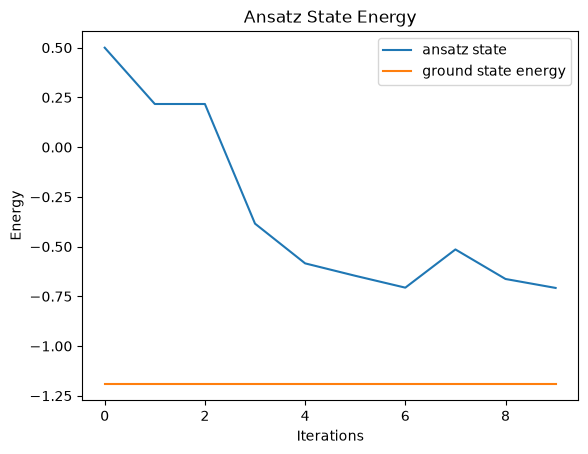

In [9]:
plt.plot(energies, label="ansatz state")
plt.plot(np.array(len(energies) * [ground_state_energy]), label="ground state energy")
plt.xlabel("Iterations")
plt.ylabel("Energy")
plt.title("Ansatz State Energy")
plt.legend()
plt.show()

### Convergence Graph

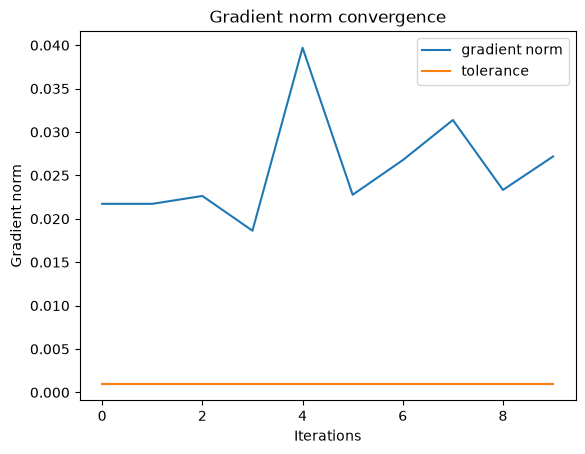

In [10]:
plt.plot(gradient_norms, label="gradient norm")
plt.plot(np.array(len(gradient_norms) * [tol]), label="tolerance")
plt.xlabel("Iterations")
plt.ylabel("Gradient norm")
plt.title("Gradient norm convergence")
plt.legend()
plt.show()

### Circuit Information

The circuit width and depth are:

In [11]:
# circuit width
print(f"circuit width: {circuit_widths[min_energy_idx]}")
# circuit depth
print(f"circuit depth: {circuit_widths[min_energy_idx]}")

circuit width: 4
circuit depth: 4


### Summary ADAPT-VQE Ansatz
For the chosen operator pool and classical optimization algorithm, the optimal ansatz state has $10$ parameters converged to a result $E_{\text{min}}= -0.707848681231239 $ The ansatz operators, indexed by their associated index in the operator pool: $[6,6,39,20,45,6,50,6,50,6]$.

The optimization parameters are: $$ \vec{\theta} = [0.5848,  0.4323,  1.5439, -0.0094,  0.8553,  0.5134,  1.7361,  0.6801,  0.7741,
  0.9886]^T~~,$$ 

The ansatz state can be constructed with a quantum circuit with a circuit width of $4$ and circuit depth of $4$.


## Modified ADAPT-VQE Ansatz

We provide a modified version of the algorithm, where the algorithm starts with a pre-optimization with respect to a chosen operator.
The algorithm showed improved results for the considered Hamiltonian and operator pool.

In [12]:
# maximum number of iterations
MAX_ITERATIONS = 10

ansatz_ops_indicies: list[int] = []
# start with default parameter
ansatz_ops_indicies.append(10)
# stores the gradient norms
gradient_norms = []

# stores the minimal gradient element in each step
picked_derivatives = []

# ansatz state energy
energies = []

# parameter history
params_history = []

# circuit depths and widths
circuit_depths = []
circuit_widths = []

# gradient norm tolerance for stopping criterion
tol: Final[float] = 0.001

for i in range(
    MAX_ITERATIONS
):  # loop until gradient norm exceeds tolerance (break-ing out of the loop)

    # number of layers (initially=1)
    K = len(ansatz_ops_indicies)

    # trace and history for analysis and plotting
    @qfunc
    def main(params: CArray[CReal, K], v: Output[QArray[QBit, NUM_QUBITS]]):
        allocate(v)
        adapt_vqe_ansatz(params, ansatz_ops_indicies, v)

    qprog = synthesize(main)
    metrics = get_transpiled_circuit_metrics(qprog)
    circuit_widths.append(metrics.width)
    circuit_depths.append(metrics.depth)

    # initial optimization parameters for the VQE re-optimization

    initial_params = np.linspace(0, 1, K).tolist()
    with ExecutionSession(qprog, execution_preferences) as es:
        optimization_results = es.variational_minimize(
            cost_function=HAMILTONIAN,  # Hamiltonian problem
            initial_params={"params": initial_params},
            max_iteration=100,
        )

    params = optimization_results[-1][1]["params"]
    params_history.append(params)
    energy = optimization_results[-1][0]
    energies.append(energy)

    ## Compute gradients of operator pool elements
    @qfunc
    def main(
        params: CArray[CReal, K],
        v: Output[QArray[QBit, NUM_QUBITS]],  # type: ignore
    ):
        allocate(v)
        adapt_vqe_ansatz(params, ansatz_ops_indicies, v)

    qprog_grads = synthesize(main)

    grad_operators = [grad_operator(op, HAMILTONIAN) for op in op_pool]
    with ExecutionSession(qprog_grads, execution_preferences) as es:
        gradient_results = es.observe(grad_operators, {"params": params})
    gradients = np.array([result.value for result in gradient_results])

    # evaluate the scaled gradient norm
    scaled_gradient_norm = np.linalg.norm(gradients) / len(gradients)
    gradient_norms.append(scaled_gradient_norm)

    # convergence check
    if scaled_gradient_norm < tol:
        print(f"Gradient converged")
        break
    elif i == MAX_ITERATIONS - 1:
        print(
            f"Iteration {i+1} completed; selected operator index: {g_idx}; partial derivative: {np.real(gradients[g_idx])}; current energy: {energy}"
        )
        print(f"Reacheck maximum number of iterations")
        break

    positive_gradient = np.all(gradients >= 0)
    if positive_gradient:
        print(f"Optimization reached a minima")
        break

    g_idx = np.argmin(gradients)
    picked_derivatives.append(gradients[g_idx])
    print(
        f"Iteration {i+1} completed; selected operator index: {g_idx}; partial derivative: {np.real(gradients[g_idx])};  current energy: {energy}"
    )

    ansatz_ops_indicies.append(g_idx)

Iteration 1 completed; selected operator index: 2; partial derivative: -0.5999999962884589;  current energy: 0.30000000185576997
Iteration 2 completed; selected operator index: 4; partial derivative: -0.3999999999498157;  current energy: 0.17573593924425335
Iteration 3 completed; selected operator index: 50; partial derivative: -0.6325932167763525;  current energy: -0.14787085528494592
Iteration 4 completed; selected operator index: 42; partial derivative: -0.19999999997092577;  current energy: -0.35808808888441596
Iteration 5 completed; selected operator index: 45; partial derivative: -0.1935246530833506;  current energy: -1.1671907029792885
Iteration 6 completed; selected operator index: 39; partial derivative: -0.4118947318048162;  current energy: -1.0911797843439324
Iteration 7 completed; selected operator index: 21; partial derivative: -0.1739847051484968;  current energy: -1.1804771751890972
Iteration 8 completed; selected operator index: 51; partial derivative: -0.36752952620070

## Results and Discussion

Ansatz state summary

In [13]:
min_energy_idx = np.argmin(np.array(energies))
optimal_energy_modified_adapt_vqe = energies[min_energy_idx]
optimized_parameters_modified_adapt_vqe = params_history[min_energy_idx]
optimized_op_idxs = ansatz_ops_indicies[: (min_energy_idx + 1)]
print(f"Optimized parameters: {np.round(optimized_parameters_modified_adapt_vqe,4)}")
print(f"Optimized energy: {optimal_energy_modified_adapt_vqe}")
error_modified_adapt_vqe = abs(
    100
    * (optimal_energy_modified_adapt_vqe - ground_state_energy)
    / ground_state_energy
)
print(f"Error: {error_modified_adapt_vqe}%")

Optimized parameters: [ 1.5757  1.8084  0.7077  0.5244 -0.1062 -0.1099  1.5939]
Optimized energy: -1.1804771751890972
Error: 0.7485862587808589%


### Energy Graph

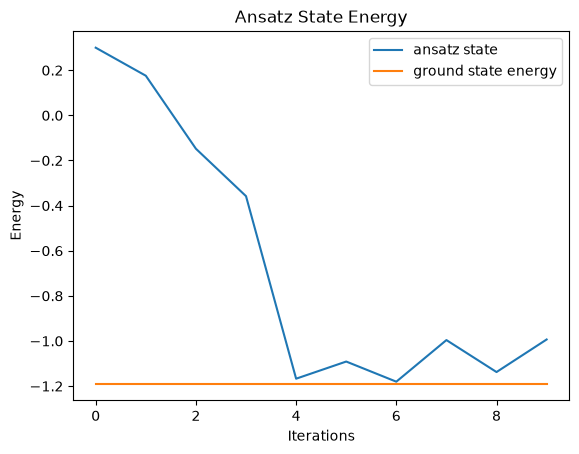

In [14]:
plt.plot(energies, label="ansatz state")
plt.plot(np.array(len(energies) * [ground_state_energy]), label="ground state energy")
plt.xlabel("Iterations")
plt.ylabel("Energy")
plt.title("Ansatz State Energy")
plt.legend()
plt.show()

### Convergence Graph

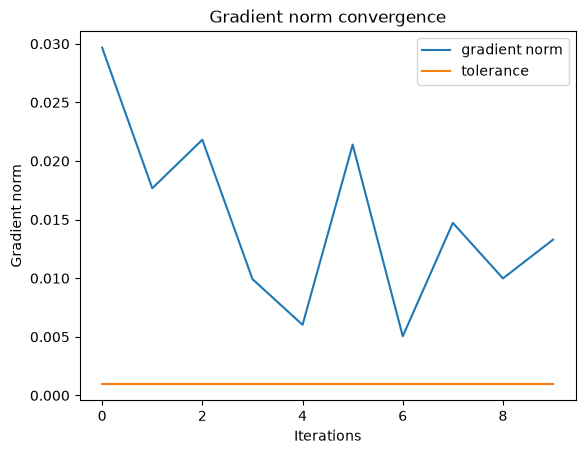

In [15]:
plt.plot(gradient_norms, label="gradient norm")
plt.plot(np.array(len(gradient_norms) * [tol]), label="tolerance")
plt.xlabel("Iterations")
plt.ylabel("Gradient norm")
plt.title("Gradient norm convergence")
plt.legend()
plt.show()

### Circuit Information

The circuit width and depth are:

In [16]:
# circuit width
print(f"circuit width: {circuit_widths[min_energy_idx]}")
# circuit depth
print(f"circuit depth: {circuit_depths[min_energy_idx]}")

circuit width: 4
circuit depth: 19


### Summary Modified ADAPT-VQE Ansatz
For the chosen operator pool and classical optimization algorithm, the optimal ansatz state has $7$ parameters converged to a result $E_{\text{min}}=-1.1804771$ The ansatz operators, indexed by their associated index in the operator pool:
$[2,4,50,42,45,39,21]$.

The optimization parameters are: $$ \vec{\theta} = [1.5757,  1.8084,  0.7077, 0.5244, -0.1062, -0.1099,  1.5939]^T~~,$$ 

The ansatz state can be constructed with a quantum circuit with a circuit width of $4$ and circuit depth of $19$.


## Comparison to the VQE Algorithm

We now validate the results of the ADAPT-VQE by comparing them to the outcome of the standard VQE algorithm with ten optimization parameters ($K=10$), and picking the operator pool as the first ten even indices (the choice is arbitrary and independent of the Hamiltonian). We fix the ansatz state by considering a product form of phases, $$|\psi_{\text{VQE}}\rangle = \Pi_{k=1}^{K} e^{-i \theta_k O_k}|0^n\rangle~~,$$ where $n=4$, for the presented test case. The operators $\{O_k\}$ are determined by their operator pool indices in `vqe_ansatz_ops_indicies` and the associated parameters $\{\theta_k\}$ are optimized by applying the VQE algorithm.


In [17]:
K = 10
modular_range = [i * 2 % len(op_pool) for i in range(K)]
modular_range = [0] + modular_range
vqe_ansatz_ops_indicies = modular_range


@qfunc
def main(params: CArray[CReal, K], v: Output[QArray[QBit, NUM_QUBITS]]):
    allocate(v)
    n = params.len
    adapt_vqe_ansatz(params, vqe_ansatz_ops_indicies, v)


qprog_vqe = synthesize(main)


with ExecutionSession(qprog_vqe) as es:
    vqe_optimization_results = es.variational_minimize(
        cost_function=HAMILTONIAN,  # Hamiltonian problem
        initial_params={"params": [0] * K},
        max_iteration=100,
    )

vqe_minimal_energy = vqe_optimization_results[-1][0]
print(f"VQE minimal energy: {vqe_minimal_energy}")

# optimized thetas (rounded)
vqe_optimized_thetas = [vqe_optimization_results[-1][1]["params"]][0]
vqe_rounded_thetas = [
    round(vqe_optimized_thetas[i], 3) for i in range(len(vqe_optimized_thetas))
]
print(f"VQE optimized thetas: {vqe_rounded_thetas}")
print(
    f"error: {abs(100*(vqe_minimal_energy-ground_state_energy)/ground_state_energy)}%"
)

VQE minimal energy: -1.0915039062499998
VQE optimized thetas: [1.641, -0.407, 1.156, 0.393, 1.731, 1.362, -0.192, -0.149, -0.216, 0.913]
error: 8.229224523530494%


### Circuit Information

In [19]:
# circuit width
metrics_vqe = get_transpiled_circuit_metrics(qprog_vqe)
print(f"circuit width: {metrics_vqe.width}")
# circuit depth
print(f"circuit depth: {metrics_vqe.depth}")

circuit width: 4
circuit depth: 26


### Summary VQE Ansatz
The VQE ansatz is characterized by:

Optimized optimization parameters:  $$\vec{\theta} = [1.536, -0.564, 1.271, 0.144, 1.94, 1.511, -0.215, -0.062, -0.391, 0.855]^T$$

The ansatz operators are originally set (an arbitrary choice):  $[0,2,4,6,8,10,12,14,16,18]$.

and minimal energy $\langle\psi^{\text{VQE}}|H |\psi^{\text{VQE}}\rangle$: $-0.96816$.

The ansatz state can be constructed with a quantum circuit with a circuit width of $4$ and circuit depth of $26$.

## Analysis and Summary

By comparing the results obtained with ADAPT-VQE, modified ADAPT-VQE and standard VQE, and exact diagonalization, we observe that for an equal number of variational parameters, modified ADAPT-VQE converges to an ansatz that yields a more accurate estimate of the ground-state energy, 
$E_{\text{g.s}}=  -1.189380715792109$. Specifically, modified ADAPT-VQE achieves an energy within approximately 
$~0.7$% of the exact value. In contrast, the original ADAPT-VQE achieves a minimal energy which is $40$% above the true ground state energy. The VQE ansatz - whose operator structure is chosen independently of the Hamiltonian - converges to an optimal energy that remains $18.6$% above the true ground-state energy.

The result highlights the potential of an ADAPT-VQE type ansatz, which is constructed iteratively based on the energy gradient, that is directly determined by the Hamiltonian under consideration.  As a consequence, only operators that most effectively lower the energy are included in the ansatz, leading to faster and more accurate convergence. The ADAPT-VQE achieves a better accuracy, with a smaller circuit depth ($4$ and $19$ compared to $26$ for the VQE). This contrasts with a general, Hamiltonian-independent ansatz, which lacks such targeted optimization and therefore exhibits inferior convergence performance and tends to require larger circuit depths to achieve the same accuracy.
Importantly, the large difference between the two variations of ADAPT-VQE proposed showcases that the algorithm doesn't guarantee better results. A clever choice of the operator pool and the initial state can potentially greatly improve the algorithm's performance.

## References

<a id='ADAPT-VQE'>[1]</a>: [Grimsley, H. R., Economou, S. E., Barnes, E., & Mayhall, N. J. (2019). An adaptive variational algorithm for exact molecular simulations on a quantum computer. Nature communications, 10(1), 3007.](https://arxiv.org/abs/1812.11173)

<a id='VQE'>[2]</a>: [Tilly, J., Chen, H., Cao, S., Picozzi, D., Setia, K., Li, Y., ... & Tennyson, J. (2022). The variational quantum eigensolver: a review of methods and best practices. Physics Reports, 986, 1-128.](https://arxiv.org/abs/2111.05176)